# 01 — Data Ingestion & Validation
> Downloads the EPA dC/dN dataset, inspects raw files, and runs schema validation.

**Run this notebook first.** All subsequent notebooks depend on the files saved in `data/raw/`.

## 0 · Google Colab Setup
_Skip if running locally — this cell auto-installs deps and mounts the repo._

In [1]:
import sys, os
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !git clone https://github.com/YOUR_USERNAME/tree_carbon_ml.git 2>/dev/null || true
    %cd tree_carbon_ml
    !pip install -r requirements.txt -q
else:
    # If running locally inside the 'notebooks' folder, move up to the project root
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')
# Add src to path
src_path = os.path.join(os.getcwd(), 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)
print(f'Environment ready. Working directory is now: {os.getcwd()}')

Environment ready. Working directory is now: C:\Users\16473\Desktop\SVM


## 1 · Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from data.download import DataDownloader
from data.validate import DataValidator, EXPECTED_COLUMNS

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Imports OK')

Imports OK


## 2 · Download Raw Data
Files are downloaded from the EPA ScienceHub and saved to `data/raw/`.

In [3]:
downloader = DataDownloader(raw_dir='data/raw')
paths = downloader.download_all(force=False)
print('\nPaths:', {k: str(v) for k, v in paths.items()})

  ↓ Downloading: dCdN_plot_data.csv


  0%|                                                                            | 0.00/25.2M [00:00<?, ?B/s]

  0%|                                                                   | 8.19k/25.2M [00:00<10:38, 39.4kB/s]

  0%|                                                                   | 32.8k/25.2M [00:00<05:03, 82.7kB/s]

  0%|▎                                                                   | 98.3k/25.2M [00:00<02:18, 181kB/s]

...

100%|███████████████████████████████████████████████████████████████████| 25.2M/25.2M [00:04<00:00, 5.33MB/s]

  ↓ Downloading: dCdN_column_key.csv


  0%|                                                                            | 0.00/2.09k [00:00<?, ?B/s]

100%|███████████████████████████████████████████████████████████████████████████| 2.09k/2.09k [00:00<?, ?B/s]


✅ All files ready.

Paths: {'main': 'data\\raw\\dCdN_plot_data.csv', 'column_key': 'data\\raw\\dCdN_column_key.csv'}


## 3 · Load & Inspect Raw Files

In [4]:
# Load column key (metadata)
col_key = pd.read_csv(paths['column_key'])
print(f'Column key shape: {col_key.shape}')
col_key

Column key shape: (23, 4)


,column names,definition,derivation,notes
0,PLT_CN,FIA PLOT ID NUMBER,from FIA plot and tree tables,NaN
1,TPH.gs.dC.dN0.01,The net dC/dN (the net change in aboveground l...,NaN,NaN
2,TPH.s.dC.dN0.01,The net dC/dN (the net change in aboveground l...,NaN,NaN
3,TPH.g.dC.dN0.01,The net dC/dN (the net change in aboveground l...,NaN,NaN
4,EXPN.ha,The FIA expansion factor in hectares for the F...,NaN,NaN
5,LAT,FIA published latitude of the plot,NaN,NaN
6,LON,FIA published longitude of the plot,NaN,NaN
7,EXPN.ha.TPH.gs.dC.dN0.01,The net dC/dN of the FIA plot fully expanded f...,NaN,NaN
8,EXPN.ha.TPH.s.dC.dN0.01,The net dC/dN of the FIA plot fully expanded f...,NaN,NaN
9,EXPN.ha.TPH.g.dC.dN0.01,The net dC/dN of the FIA plot fully expanded f...,NaN,NaN


In [5]:
# Load main dataset
df_raw = pd.read_csv(paths['main'])
print(f'Main dataset shape: {df_raw.shape}')
print(f'Columns ({len(df_raw.columns)}): {df_raw.columns.tolist()}')

Main dataset shape: (110650, 23)
Columns (23): ['PLT_CN', 'TPH.gs.dC.dN0.01', 'TPH.s.dC.dN0.01', 'TPH.g.dC.dN0.01', 'EXPN.ha', 'LAT', 'LON', 'EXPN.ha.TPH.gs.dC.dN0.01', 'EXPN.ha.TPH.s.dC.dN0.01', 'EXPN.ha.TPH.g.dC.dN0.01', 'US_L4CODE', 'NA_L3CODE', 'NA_L1CODE', 'STATECD', 'COUNTYCD', 'e3', 'e1', 'e4', 'e3.state', 'e4.state', 'e1.state', 'eco.EXPN.ha', 'state.EXPN.ha']


In [6]:
# First 5 rows
df_raw.head()

,PLT_CN,TPH.gs.dC.dN0.01,TPH.s.dC.dN0.01,TPH.g.dC.dN0.01,EXPN.ha,LAT,LON,EXPN.ha.TPH.gs.dC.dN0.01,EXPN.ha.TPH.s.dC.dN0.01,EXPN.ha.TPH.g.dC.dN0.01,US_L4CODE,NA_L3CODE,NA_L1CODE,STATECD,COUNTYCD,e3,e1,e4,e3.state,e4.state,e1.state,eco.EXPN.ha,state.EXPN.ha
0,106313473010478,6.4108,-33.3048,39.7156,2407.4985,31.3290,-88.3549,15434.0742,-80181.1827,95615.2568,65f,8.3.5,8.0000,1,129,8.3.5,8.0000,65f,8.3.5,65f,8,148681549.1796,9965556.6875
1,106313107010478,0.0000,0.0000,0.0000,2397.3487,31.2464,-88.2513,0.0000,0.0000,0.0000,65f,8.3.5,8.0000,1,129,8.3.5,8.0000,65f,8.3.5,65f,8,148681549.1796,9965556.6875
2,106331005010478,15.3826,-2.7670,18.1496,2367.5412,31.3412,-85.6098,36418.8536,-6551.0965,42969.9501,65d,8.3.5,8.0000,1,45,8.3.5,8.0000,65d,8.3.5,65d,8,148681549.1796,9965556.6875
3,148457308010478,2.4036,-8.4161,10.8197,2397.3487,30.5975,-87.5287,5762.2120,-20176.3649,25938.5769,65f,8.3.5,8.0000,1,3,8.3.5,8.0000,65f,8.3.5,65f,8,148681549.1796,9965556.6875
4,148434783010478,28.9510,-32.8030,61.7540,2407.4985,31.4261,-87.9188,69699.5480,-78973.1351,148672.6831,65p,8.3.5,8.0000,1,129,8.3.5,8.0000,65p,8.3.5,65p,8,148681549.1796,9965556.6875


In [7]:
# Data types and non-null counts
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110650 entries, 0 to 110649
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   PLT_CN                    110650 non-null  int64  
 1   TPH.gs.dC.dN0.01          110650 non-null  float64
 2   TPH.s.dC.dN0.01           110650 non-null  float64
 3   TPH.g.dC.dN0.01           110650 non-null  float64
 4   EXPN.ha                   110650 non-null  float64
 5   LAT                       110650 non-null  float64
 6   LON                       110650 non-null  float64
 7   EXPN.ha.TPH.gs.dC.dN0.01  110650 non-null  float64
 8   EXPN.ha.TPH.s.dC.dN0.01   110650 non-null  float64
 9   EXPN.ha.TPH.g.dC.dN0.01   110650 non-null  float64
 10  US_L4CODE                 110621 non-null  object 
 11  NA_L3CODE                 110621 non-null  object 
 12  NA_L1CODE                 110621 non-null  float64
 13  STATECD                   110650 non-null  i

In [8]:
# Basic statistics
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PLT_CN,110650.0000,NaN,NaN,NaN,165250071672457.9375,103194279949036.0469,3501890010945.0000,40394824760690.0000,197125885010854.0000,249673074510854.0000,375817800489998.0000
TPH.gs.dC.dN0.01,110650.0000,NaN,NaN,NaN,7.6443,53.2102,-602.5176,-5.7120,1.3699,15.6076,2128.6021
TPH.s.dC.dN0.01,110650.0000,NaN,NaN,NaN,-13.8162,42.0836,-634.7375,-18.8797,-5.7937,-0.1420,1916.8751
TPH.g.dC.dN0.01,110650.0000,NaN,NaN,NaN,21.4605,36.3950,-189.9031,2.2448,10.3338,26.9763,1225.6522
EXPN.ha,110650.0000,NaN,NaN,NaN,2526.0148,2902.5911,391.7343,2052.3153,2407.4616,2573.3817,67463.7055
LAT,110650.0000,NaN,NaN,NaN,39.7658,5.4561,25.3825,35.2039,39.5917,44.7030,49.3489
LON,110650.0000,NaN,NaN,NaN,-94.0643,15.5102,-124.7004,-108.6747,-90.2461,-82.6669,-67.0122
EXPN.ha.TPH.gs.dC.dN0.01,110650.0000,NaN,NaN,NaN,18756.3480,169478.6756,-4631891.3722,-12298.1789,2783.0100,32272.7648,11670586.8414
EXPN.ha.TPH.s.dC.dN0.01,110650.0000,NaN,NaN,NaN,-33347.8271,133793.0893,-6357755.4553,-42067.4272,-12071.2831,-269.3121,7936996.8325
EXPN.ha.TPH.g.dC.dN0.01,110650.0000,NaN,NaN,NaN,52104.1751,124937.6235,-2409687.2308,4827.2901,21398.3010,58086.1779,9501393.3701


## 4 · Schema Validation

In [9]:
validator = DataValidator(df_raw)
validator.run_all().report()

✅ All validation checks passed.


True

## 5 · Missing Value Overview

In [10]:
missing = df_raw.isna().sum().sort_values(ascending=False)
missing_pct = (df_raw.isna().mean() * 100).sort_values(ascending=False)

summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print('Columns with any missing values:')
display(summary[summary.missing_count > 0])
print(f'\nTotal rows: {len(df_raw):,}')

Columns with any missing values:


,missing_count,missing_pct
NA_L3CODE,29,0.0262
NA_L1CODE,29,0.0262
e4,29,0.0262
e1,29,0.0262
e3,29,0.0262
US_L4CODE,29,0.0262



Total rows: 110,650


## 6 · Duplicate Check

In [11]:
n_dupes = df_raw.duplicated(subset=['PLT_CN']).sum()
print(f'Duplicate PLT_CN rows: {n_dupes}')
print(f'Unique plots: {df_raw["PLT_CN"].nunique():,}')

Duplicate PLT_CN rows: 0
Unique plots: 110,650


## 7 · Geographic Coverage

Latitude  range: 25.382516 → 49.348905
Longitude range: -124.700359 → -67.01218
States covered : 48
Counties covered: 194


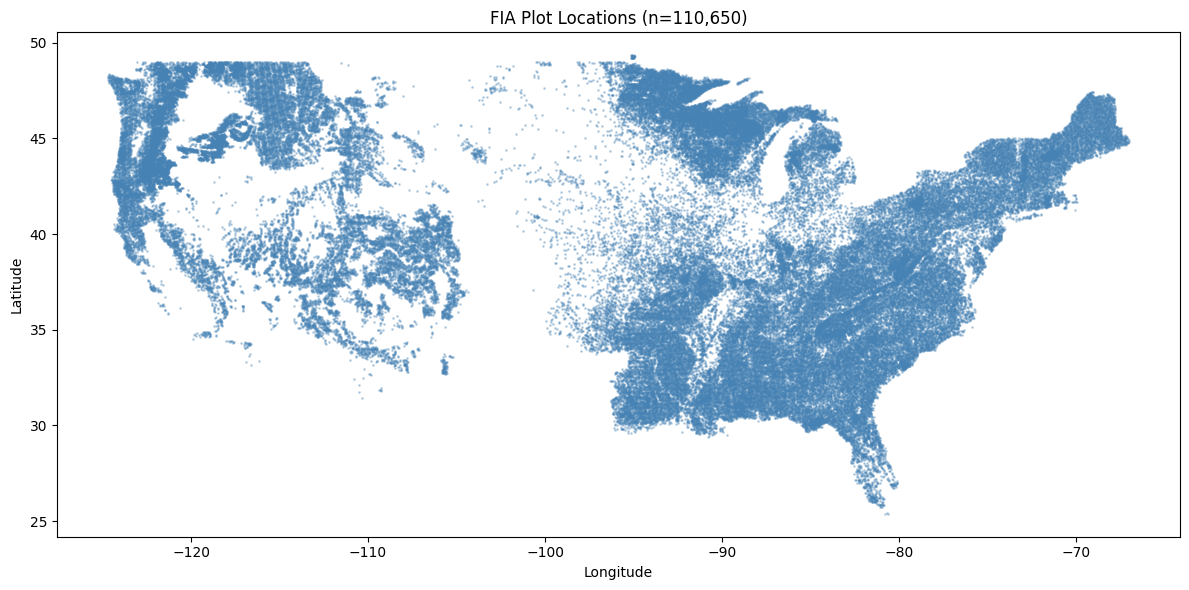

In [12]:
print('Latitude  range:', df_raw['LAT'].min(), '→', df_raw['LAT'].max())
print('Longitude range:', df_raw['LON'].min(), '→', df_raw['LON'].max())
print('States covered :', df_raw['STATECD'].nunique())
print('Counties covered:', df_raw['COUNTYCD'].nunique())

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df_raw['LON'], df_raw['LAT'], s=1, alpha=0.3, c='steelblue')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'FIA Plot Locations (n={len(df_raw):,})')
plt.tight_layout(); plt.show()

## 8 · Ecoregion Coverage

In [13]:
for col in ['NA_L1CODE','NA_L3CODE','US_L4CODE']:
    print(f'{col}: {df_raw[col].nunique()} unique values')

NA_L1CODE: 10 unique values
NA_L3CODE: 81 unique values
US_L4CODE: 778 unique values


## 9 · Save Validated Raw Copy
Save a clean copy (renamed columns, parsed types) as the canonical input for downstream notebooks.

In [14]:
!pip install pyarrow

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import os
os.makedirs('data/interim', exist_ok=True)

# Cast PLT_CN to string for safe joins
df_raw['PLT_CN'] = df_raw['PLT_CN'].astype(str)

out_path = 'data/interim/01_raw_validated.parquet'
df_raw.to_parquet(out_path, index=False)
print(f'Saved to {out_path}  shape={df_raw.shape}')

Saved to data/interim/01_raw_validated.parquet  shape=(110650, 23)


---
### ✅ Notebook 01 Complete
Next: **02_eda_exploration.ipynb**